# Homework 7

Isaac Adoboe -  ieadoboe@mun.ca

## Question 1

In [91]:
# Import libraries
import numpy as np
from datetime import datetime

In [92]:
# Define function
def f(x): return np.sin(x**2)


# Function returns python lists
def py_list_eval(nsample, function=f):
    x_list = []
    f_list = []

    x = np.linspace(0, 1, nsample+1)
    f_x = function(x)

    for x_i in x:
        x_list.append(x_i)
    for f_i in f_x:
        f_list.append(f_i)

    return x_list, f_list


# Function returns python ndarrays
def py_ndarray_eval(nsample, function=f):
    x = np.linspace(0, 1, nsample+1)
    f_x = function(x)
    return x, f_x

In [93]:
py_list_eval(nsample=2)

([np.float64(0.0), np.float64(0.5), np.float64(1.0)],
 [np.float64(0.0),
  np.float64(0.24740395925452294),
  np.float64(0.8414709848078965)])

In [94]:
py_ndarray_eval(nsample=2)

(array([0. , 0.5, 1. ]), array([0.        , 0.24740396, 0.84147098]))

In [ ]:
print("For python lists")
print("-"*50)
for x in range(9):
    nsample = 10**x
    start = datetime.now()
    py_list_eval(nsample=nsample)
    end = datetime.now()
    elapsed = (end-start).total_seconds()
    print(f"For {nsample} number of samples, it took {elapsed:.8f} seconds")

For python lists
--------------------------------------------------
For 1 number of samples, it took 0.00006400 seconds
For 10 number of samples, it took 0.00001600 seconds
For 100 number of samples, it took 0.00002000 seconds
For 1000 number of samples, it took 0.00009700 seconds
For 10000 number of samples, it took 0.00105200 seconds
For 100000 number of samples, it took 0.01069600 seconds
For 1000000 number of samples, it took 0.08464800 seconds
For 10000000 number of samples, it took 0.82357100 seconds


In [ ]:
print("For python np.ndarray")
print("-"*50)
for x in range(9):
    nsample = 10**x
    start = datetime.now()
    py_ndarray_eval(nsample=nsample)
    end = datetime.now()
    elapsed = (end-start).total_seconds()
    print(f"For {nsample} number of samples, time: {elapsed:.8f} seconds")

For python np.ndarray
--------------------------------------------------
For 1 number of samples, it took 0.00008700 seconds
For 10 number of samples, it took 0.00002100 seconds
For 100 number of samples, it took 0.00001600 seconds
For 1000 number of samples, it took 0.00019900 seconds
For 10000 number of samples, it took 0.00088400 seconds
For 100000 number of samples, it took 0.00262500 seconds
For 1000000 number of samples, it took 0.00856200 seconds
For 10000000 number of samples, it took 0.06198700 seconds
For 100000000 number of samples, it took 0.99070900 seconds
For 1000000000 number of samples, it took 45.49524600 seconds


**Comments:**

* For 1 million samples, numpy (ndarray version) is over 8 times faster (0.0103s vs 0.0825s) as compared to the python lists version. This ratio widens as `nsample` increases
* At smaller values of `nsample` (`nsample=1`, `nsample=10` & `nsample=100`), the lists looping approach can be faster than (or comparable to) the numpy ndarray approach.
* It is clear that for very large values of `nsample`, the benefits of the numpy ndarrays become clear.
* For trivial problem sizes, the implementation choice doesn't really matter. For realistic scientific computing problems (sizes), numpy arrays has the most performance benefits and are highly recommended.

## Question 2

In [19]:
# Import libraries
import numpy as np
import scipy.special as special
import matplotlib.pyplot as plt
from common import mpl_apply

In [20]:
# Apply mpl config
mpl_apply()

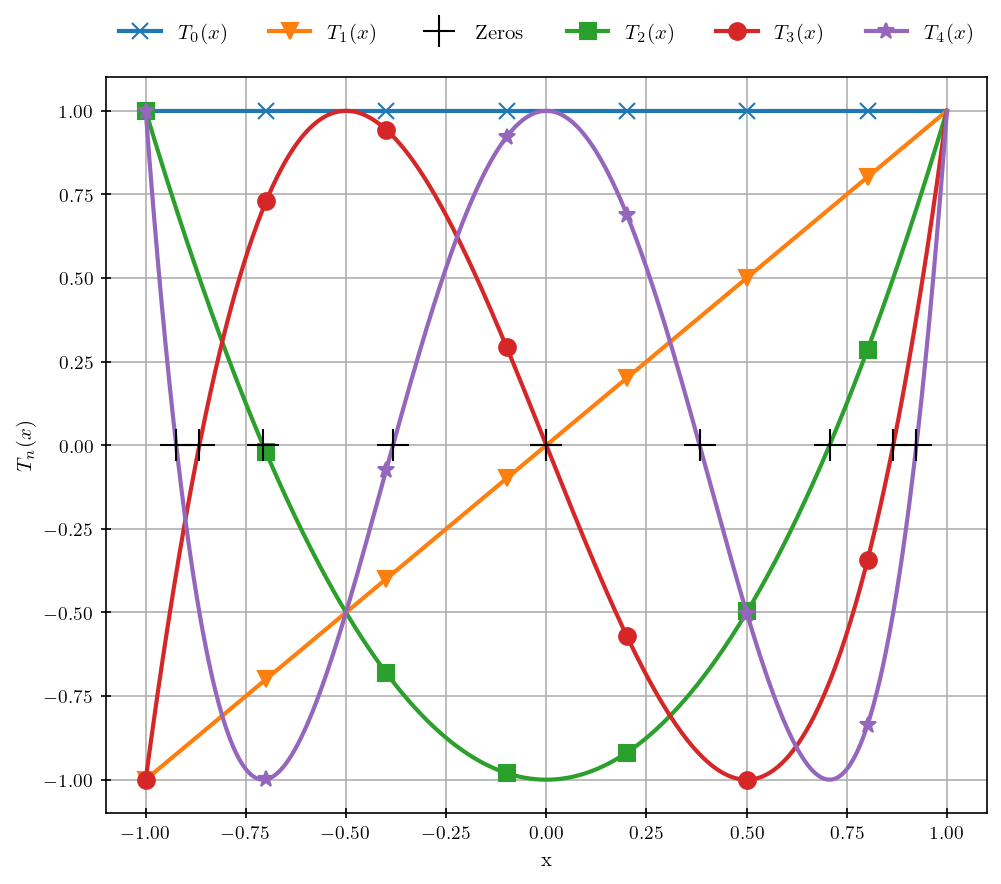

In [21]:
markers = ["x", "v", "s", "o", "*"]

x = np.linspace(-1, 1, 1000)
zero_plotted = False

plt.figure(figsize=(7, 6))
for n in range(5):
    y = special.eval_chebyt(n, x)
    plt.plot(x, y, label=f"$T_{n}(x)$",
             marker=markers[n], markevery=150, markersize=8)

    if n > 0:  # T_0 has no zeros
        zeros = np.cos((2*np.arange(1, n+1) - 1) * np.pi / (2*n))
        # Only add label once to avoid duplicate legend entries
        label = "Zeros" if not zero_plotted else None
        plt.plot(zeros, np.zeros_like(zeros),
                 'k+', markersize=15, label=label)
        zero_plotted = True

plt.xlabel('x')
plt.ylabel('$T_n(x)$')

plt.legend(loc='upper center', bbox_to_anchor=(
    0.5, 1.1), ncol=6, frameon=False)
plt.tight_layout()
plt.grid()

## Question 3

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp

### `interp1d`

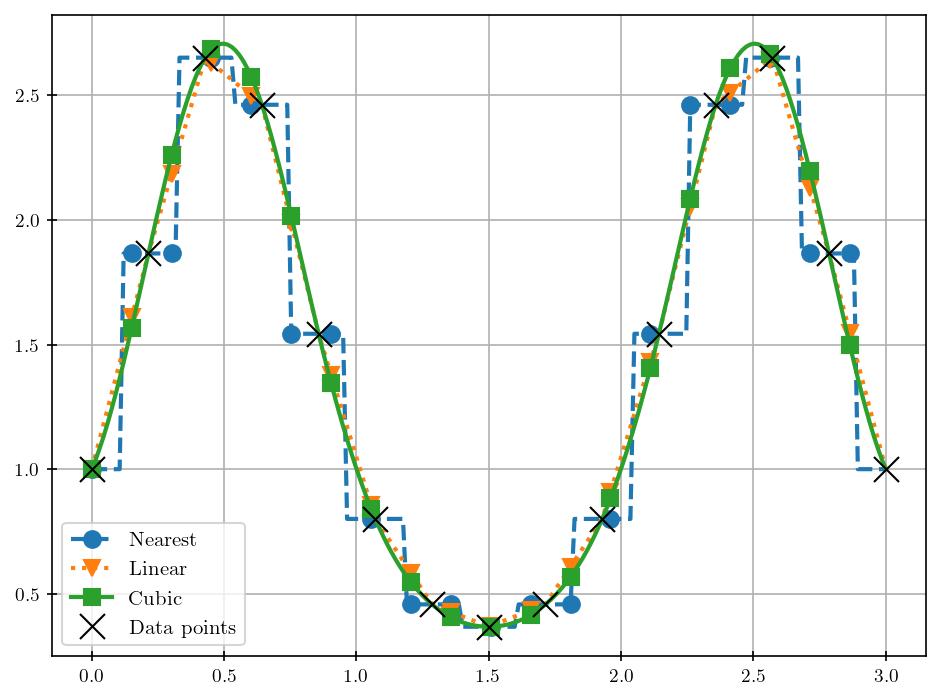

In [63]:
# Function
def f(x):
    return np.e**(np.sin(np.pi*x))


# Data points
x = np.linspace(0, 3, 15)
y = f(x)

x_fine = np.linspace(0, 3, 200)

# interpolants
g_nearest = interp.interp1d(x, y, kind='nearest')
g_linear = interp.interp1d(x, y, kind='linear')
g_cubic = interp.interp1d(x, y, kind='cubic')

y_nearest = g_nearest(x_fine)
y_linear = g_linear(x_fine)
y_cubic = g_cubic(x_fine)

kwargs = {"markevery": 10,
          "markersize": 8}

# Plot
plt.plot(x_fine, y_nearest, label="Nearest",
         linestyle="--", marker="o", **kwargs)
plt.plot(x_fine, y_linear, label="Linear",
         linestyle=":", marker="v", **kwargs)
plt.plot(x_fine, y_cubic,  label="Cubic",
         linestyle="-", marker="s", **kwargs)
plt.plot(x, y, 'kx ', label="Data points", markersize=12)

plt.legend()
plt.grid()
plt.tight_layout()

### `CubicSpline`

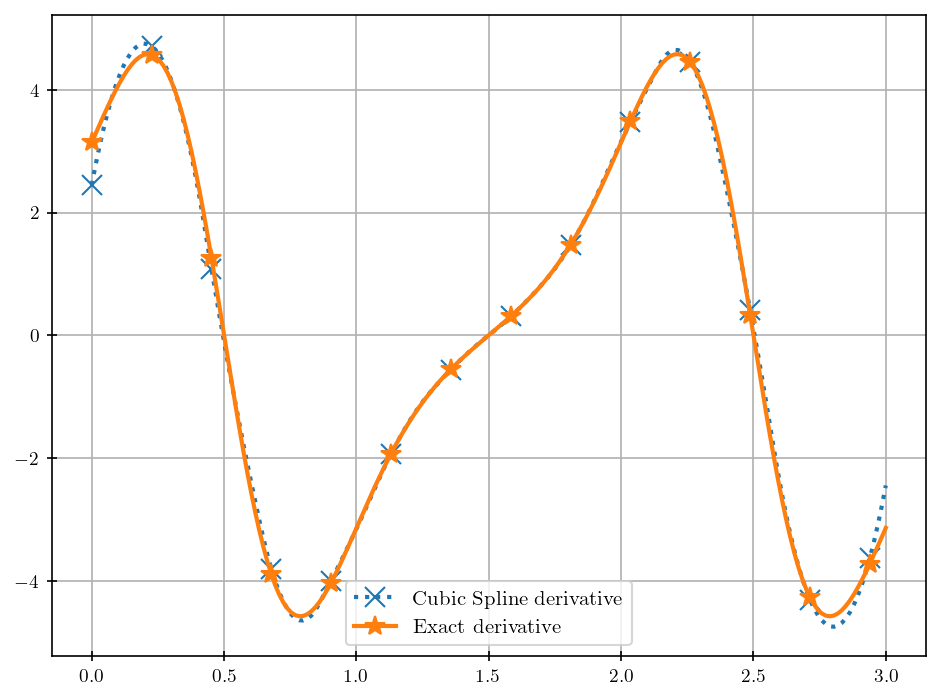

In [ ]:
def f(x):
    return np.e**(np.sin(np.pi*x))


# Data points
x = np.linspace(0, 3, 15)
y = f(x)

# Sample points
x_fine = np.linspace(0, 3, 200)


# Exact derivative
def f_prime(x):
    return np.e**(np.sin(np.pi*x)) * np.cos(np.pi*x) * np.pi


d = f_prime(x_fine)

# Cubic spline
gspline = interp.CubicSpline(x, y, bc_type='not-a-knot')

# derivative function
dg = gspline.derivative()
d_fine = dg(x_fine)


kwargs = {"markevery": 15,
          "markersize": 10}

# Plot
plt.plot(x_fine, d_fine, label="Cubic Spline derivative",
         linestyle=":", marker="x", **kwargs)
plt.plot(x_fine, d, label="Exact derivative",
         linestyle="-", marker="*", **kwargs)

plt.legend()
plt.grid()
plt.tight_layout()

### `fixed_quad`

In [115]:
import scipy.integrate as integrate
import numpy as np

In [116]:
def f(x):
    return np.e**(np.sin(np.pi*x))

In [ ]:
for n in range(1, 21):
    val = integrate.fixed_quad(f, 0, 3, n=n)
    print(f"With order {n}, approximation is {val[0]}")

With order 1, approximation is 1.103638323514327
With order 2, approximation is 7.473298640663884
With order 3, approximation is 4.482331852412473
With order 4, approximation is 3.9367345442412
With order 5, approximation is 4.674223744064444
With order 6, approximation is 4.555405996923763
With order 7, approximation is 4.469432470895808
With order 8, approximation is 4.513436874383119
With order 9, approximation is 4.512000409516655
With order 10, approximation is 4.506793843844232
With order 11, approximation is 4.508517558242957
With order 12, approximation is 4.508595517848832
With order 13, approximation is 4.508388292755122
With order 14, approximation is 4.508440814062365
With order 15, approximation is 4.508445730325365
With order 16, approximation is 4.508439424373909
With order 17, approximation is 4.508440788439414
With order 18, approximation is 4.5084409443458995
With order 19, approximation is 4.508440786690819
With order 20, approximation is 4.508440818431111


In [129]:
integrate.fixed_quad(f, 0, 3, n=20)

(np.float64(4.508440818431111), None)

In [131]:
integrate.quad(f, 0, 3)

(4.508440819193944, 1.2587343389824923e-09)

Timings:

In [127]:
%timeit integrate.fixed_quad(f, 0, 3, n=20)

6.76 μs ± 116 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [128]:
%timeit integrate.quad(f, 0, 3)

37.6 μs ± 1.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


**Comments**

* The difference between the two methods (`fixed_quad` vs `quad`) is very small ($<10^{-8}$) after order 20 with `fixed_quad`. It is important to note that convergence was not immediate and took a few tunction evaluations to stabilize as seen for `fixed_quad`.
* `fixed_quad(n=20)` is more than 5 times faster than `quad`.
* That said, even though `fixed_quad` is faster, it requires that you know (have an idea) in advance the number of point evaluations you would need to reach convergence.

## Question 4

In [135]:
# Import libraries
import numpy as np
import scipy.optimize as optim

In [ ]:
# Function
def f(vector):
    x, y = vector
    return (1000*x*y - 1)**2 + (np.e**(-x) + np.e**(-y) - 1.0001)**2


# Initial guess
x0 = np.array([0, 1])
print(x0)

[0 1]


In [168]:
x0[1]

np.int64(1)

### 4(a) - BFGS without providing the Jacobian

In [182]:
out = optim.minimize(f, x0,
                     tol=0.3)
print(out)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.13452737499665238
        x: [ 1.000e-03  1.000e+00]
      nit: 1
      jac: [-2.717e-01 -2.694e-01]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 9
     njev: 3


### 4(b) - BFGS with providing the Jacobian

In [ ]:
def df(xy):
    x, y = xy
    u = 1000*x*y - 1
    v = np.e**(-x) + np.e**(-y) - 1.0001

    df_dx = 2*u*1000*y + 2*v*(-np.e**(-x))
    df_dy = 2*u*1000*x + 2*v*(-np.e**(-y))

    return np.array([df_dx, df_dy])

In [186]:
out = optim.minimize(f, x0, jac=df)
print(out)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.3652266886087658e-20
        x: [ 1.187e-04  8.428e+00]
      nit: 119
      jac: [ 1.082e-06  1.519e-11]
 hess_inv: [[ 2.388e-03 -1.696e+02]
            [-1.696e+02  1.205e+07]]
     nfev: 151
     njev: 151


### 4(c) - Newton-CG with providing the Jacobian but not the Hessian

In [ ]:
out = optim.minimize(f, x0, jac=df, method="Newton-CG")
print(out)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.07542838249003755
       x: [ 7.759e-04  1.289e+00]
     nit: 5
     jac: [-1.416e+01 -1.595e-01]
    nfev: 8
    njev: 21
    nhev: 0


### 4(d) - Newton-CG with providing both the Jacobian and the Hessian

In [ ]:
def Hf(xy):
    x, y = xy
    u = 1000*x*y - 1
    v = np.e**(-x) + np.e**(-y) - 1.0001

    h_xx = 2*1000**2*y**2 + 2*np.e**(-2*x)
    h_yy = 2*1000**2*x**2 + 2*np.e**(-2*y)
    h_xy = 2*1000**2 + 2*np.e**(-x-y)

    return np.array([[h_xx, h_xy],
                     [h_xy, h_yy]])

In [194]:
out = optim.minimize(f, x0, jac=df, hess=Hf, method="Newton-CG")
print(out)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.13452734201005137
       x: [ 1.000e-03  1.000e+00]
     nit: 2
     jac: [-5.400e-01 -2.697e-01]
    nfev: 3
    njev: 3
    nhev: 2


### 4(e) Nelder-Mead

In [193]:
out = optim.minimize(f, x0, method='Nelder-Mead',
                     options={'maxiter': 5000})
print(out)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 6.830993530576365e-17
             x: [ 1.187e-04  8.428e+00]
           nit: 260
          nfev: 477
 final_simplex: (array([[ 1.187e-04,  8.428e+00],
                       [ 1.187e-04,  8.428e+00],
                       [ 1.187e-04,  8.428e+00]]), array([ 6.831e-17,  1.084e-16,  3.003e-16]))
